# Corporate Signal Intelligence
## Notebook 03: Exploratory Data Analysis & Statistical Characterisation

Anomaly detection is only meaningful against a description of what *normal* looks like.
This notebook establishes that description formally, because the properties of financial
return series decide which detectors can work at all: a method that assumes normality,
independence or constant variance will mis-calibrate on data that has none of those
properties, and it will do so silently.

Each section states a hypothesis, tests it, and records what the answer forces the
modelling stage to do.

| # | Question | Test | Why the modelling stage cares |
|---|---|---|---|
| 1 | Are returns normally distributed? | Jarque-Bera, D'Agostino, moments | fixes whether a ±3σ rule is calibrated |
| 2 | Are the series stationary? | ADF, KPSS | decides whether features use levels or changes |
| 3 | Is there serial dependence? | Ljung-Box | tells us whether today informs tomorrow |
| 4 | Does volatility cluster? | ARCH-LM, GARCH(1,1) | decides if "surprise" needs a conditional scale |
| 5 | Do the issuers move together? | correlation, rolling mean correlation | separates market-wide from firm-specific events |
| 6 | Are there distinct regimes? | drawdown and volatility by period | determines what a single trained model must span |
| 7 | Do disclosures move prices? | market-model event study, t-tests | justifies combining filings with market data |

The event study in section 7 is the load-bearing one for the project as a whole. The
entire premise, that combining SEC filings with market behaviour beats using either
alone, rests on filings carrying measurable information, and that is a testable claim
rather than an assumption.

In [1]:
# Dependencies for the statistical analysis

%pip install -q statsmodels arch scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Environment, style and the analytical panel

import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.stattools import adfuller, kpss, acf

sys.path.append("notebooks")
import csi_viz as viz

warnings.filterwarnings("ignore")
viz.apply_style()

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 170)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

DATA_DIR = Path("data")
TRADING_DAYS = 252

UNIVERSE = [
    "AAPL", "MSFT", "NVDA", "GOOGL", "AMZN",
    "META", "TSLA", "AMD", "INTC", "ORCL",
]

# Stress episodes, dated from peak to trough of the broad US market.
REGIMES = {
    "Colapso ponto-com": ("2000-03-10", "2002-10-09"),
    "Crise financeira global": ("2007-10-09", "2009-03-09"),
    "Choque da COVID": ("2020-02-19", "2020-03-23"),
    "Queda de 2022": ("2022-01-03", "2022-10-14"),
}

market_df = pd.read_csv(DATA_DIR / "clean_market_data.csv", parse_dates=["date"])
filings_df = pd.read_csv(
    DATA_DIR / "clean_sec_filings.csv",
    parse_dates=["filing_date", "report_date", "next_trading_session"],
)

market_df = market_df.sort_values(["ticker", "date"]).reset_index(drop=True)
market_df["log_return"] = np.log(
    market_df["close"] / market_df.groupby("ticker")["close"].shift(1)
)

returns_wide = market_df.pivot(index="date", columns="ticker", values="log_return")[UNIVERSE]

print(f"Panel: {market_df['date'].min():%Y-%m-%d} to {market_df['date'].max():%Y-%m-%d}")
print(f"{len(market_df):,} issuer-days | {returns_wide.notna().to_numpy().sum():,} usable returns")

Panel: 1994-01-03 to 2026-05-21
67,912 issuer-days | 67,902 usable returns


---

## 1. Are daily returns normally distributed?

The question is not academic. A great deal of practical anomaly detection reduces to
"flag anything beyond three standard deviations", and that rule inherits its meaning from
the normal distribution: under normality, ±3σ should capture 99.73% of days, leaving
about one flagged day per year. If returns have heavier tails, the same rule fires far
more often than intended, and the excess is not anomalous at all: it is what the
distribution does routinely.

In [3]:
# Distributional moments and normality tests, issuer by issuer

normality_rows = []
for ticker in UNIVERSE:
    series = returns_wide[ticker].dropna()
    jarque_bera = stats.jarque_bera(series)
    normality_rows.append({
        "ticker": ticker,
        "observations": len(series),
        "annual_return_pct": 100 * series.mean() * TRADING_DAYS,
        "annual_volatility_pct": 100 * series.std() * np.sqrt(TRADING_DAYS),
        "skewness": stats.skew(series),
        "excess_kurtosis": stats.kurtosis(series),
        "jarque_bera": jarque_bera.statistic,
        "jb_p_value": jarque_bera.pvalue,
        "worst_day_pct": 100 * np.expm1(series.min()),
        "best_day_pct": 100 * np.expm1(series.max()),
    })

normality_df = pd.DataFrame(normality_rows).set_index("ticker")
normality_df.round(3)

,observations,annual_return_pct,annual_volatility_pct,skewness,excess_kurtosis,jarque_bera,jb_p_value,worst_day_pct,best_day_pct
ticker,,,,,,,,,
AAPL,8149,22.3210,42.5450,-2.2890,73.9670,"1,864,786.3190",0.0000,-51.8480,33.2530
MSFT,8148,16.9790,30.7320,-0.0770,7.1700,"17,460.4710",0.0000,-15.5990,19.5550
NVDA,6873,31.8120,59.1570,-0.1500,12.2150,"42,751.9900",0.0000,-35.2600,42.4950
GOOGL,5473,23.2350,30.5130,0.3320,7.6220,"13,349.3960",0.0000,-11.6340,19.9890
AMZN,7293,27.7820,54.3300,0.4560,9.8070,"29,475.8640",0.0000,-24.7660,34.4710
META,3521,19.7910,39.7230,-0.4120,21.2710,"66,481.6320",0.0000,-26.3900,29.6110
TSLA,3998,37.2780,57.7910,0.2060,6.2810,"6,600.8200",0.0000,-21.0630,40.5300
AMD,8149,12.0860,61.2380,-0.0500,7.9430,"21,427.8800",0.0000,-32.4020,52.2900
INTC,8149,11.8880,40.3710,-0.3240,10.1820,"35,342.8680",0.0000,-26.0590,23.6000


In [4]:
# How often does a Gaussian rule actually fire?

pooled_returns = returns_wide.stack().to_numpy()

standardised = pd.DataFrame({
    ticker: (returns_wide[ticker] - returns_wide[ticker].mean()) / returns_wide[ticker].std()
    for ticker in UNIVERSE
}).stack()

sigma_rows = []
for threshold in (2, 3, 4, 5):
    observed = float((standardised.abs() > threshold).mean())
    expected = 2 * stats.norm.sf(threshold)
    sigma_rows.append({
        "threshold": f"±{threshold}σ",
        "expected_under_normal_pct": 100 * expected,
        "observed_pct": 100 * observed,
        "times_more_frequent": observed / expected,
        "observed_days_per_year": observed * TRADING_DAYS,
        "expected_days_per_year": expected * TRADING_DAYS,
    })

pd.DataFrame(sigma_rows).set_index("threshold").round(3)

,expected_under_normal_pct,observed_pct,times_more_frequent,observed_days_per_year,expected_days_per_year
threshold,,,,,
±2σ,4.5500,4.1520,0.9130,10.4630,11.4660
±3σ,0.2700,1.2880,4.7720,3.2470,0.6800
±4σ,0.0060,0.5440,85.8130,1.3700,0.0160
±5σ,0.0000,0.2210,"3,852.3930",0.5570,0.0000


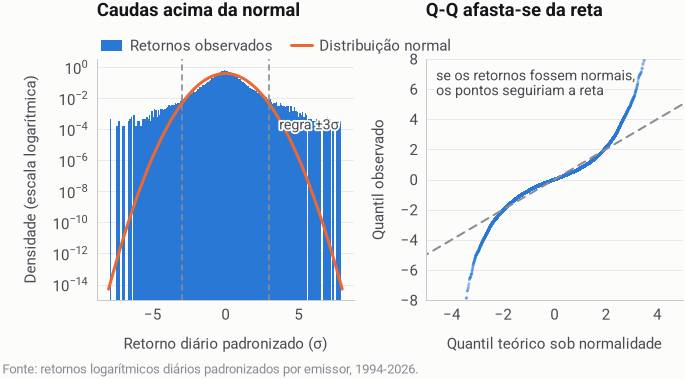

In [5]:
# Figure: the tails are far heavier than a normal distribution allows

fig, axes = plt.subplots(1, 2, figsize=(6.30, 2.61))

sample = standardised.dropna().to_numpy()

ax = axes[0]
ax.hist(
    sample, bins=180, range=(-8, 8), density=True,
    color=viz.CATEGORICAL[0], edgecolor="none", label="Retornos observados",
)
grid = np.linspace(-8, 8, 400)
ax.plot(grid, stats.norm.pdf(grid), color=viz.CATEGORICAL[1], linewidth=1.8,
        label="Distribuição normal")
ax.set_yscale("log")
ax.set_xlabel("Retorno diário padronizado (σ)")
ax.set_ylabel("Densidade (escala logarítmica)")
viz.legend_above(ax, ncols=2)
for limite in (-3, 3):
    ax.axvline(limite, color=viz.INK_MUTED, linewidth=1.0, linestyle=(0, (3, 3)))
ax.annotate(
    "regra ±3σ", xy=(3, 1e-4), xytext=(6, 0), textcoords="offset points",
    fontsize=8.5, color=viz.INK_SECONDARY,
)
viz.title(ax, "Caudas acima da normal", legend_rows=1)

ax = axes[1]
theoretical = stats.norm.ppf((np.arange(1, len(sample) + 1) - 0.5) / len(sample))
ax.scatter(theoretical, np.sort(sample), s=3, color=viz.CATEGORICAL[0], alpha=0.35,
           edgecolors="none")
limit = 8
ax.plot([-limit, limit], [-limit, limit], color=viz.INK_MUTED, linewidth=1.2,
        linestyle=(0, (4, 3)))
ax.set_xlim(-5, 5)
ax.set_ylim(-limit, limit)
ax.set_xlabel("Quantil teórico sob normalidade")
ax.set_ylabel("Quantil observado")
ax.annotate(
    "se os retornos fossem normais,\nos pontos seguiriam a reta",
    xy=(0, 0), xytext=(-4.6, 5.6), fontsize=8.5, color=viz.INK_SECONDARY,
)
viz.title(ax, "Q-Q afasta-se da reta", legend_rows=1)

fig.subplots_adjust(wspace=0.28)
viz.source_note(fig, "Fonte: retornos logarítmicos diários padronizados por emissor, 1994-2026.")

viz.save_fig(fig, "05_return_distribution")
plt.show()

Every issuer rejects normality at any conventional significance level, and the rejection
is not marginal: the Jarque-Bera statistics run from the thousands into the millions
where the 1% critical value is 9.2. Excess kurtosis of 6 to 22 against 0 for a normal
distribution is the signature of fat tails, and Apple's 74 is driven by the single −52%
session of September 2000.

The practical consequence is in the threshold table, and it is sharper than the moments
suggest. At ±2σ the empirical and Gaussian frequencies almost coincide, so the centre of
the distribution is unremarkable. The divergence is entirely in the tails: a ±3σ rule
should fire 0.7 times a year and instead fires 3.2 times, and at ±5σ, where a normal
distribution predicts one day in roughly two thousand years, these series deliver one
every other year, some four thousand times too often.

**This rules out the naive approach and motivates the project's method.** A fixed Gaussian
cut-off cannot separate "rare" from "anomalous" here, because the distribution generates
extreme moves routinely. What is needed is either a non-parametric detector that learns
the empirical density rather than assuming a shape, or a conditional model that rescales
each day by the volatility prevailing at the time. The modelling notebook benchmarks both
against exactly this Gaussian baseline.

---

## 2. Are the series stationary?

Most statistical learning assumes the data-generating process is stable. A price series
is not: it trends, and its variance grows with time. Formally the question is whether
each series has a unit root.

Two complementary tests are used because they disagree in an informative way. The
**Augmented Dickey-Fuller** test takes a unit root as its null hypothesis, so rejecting it
is evidence *for* stationarity. **KPSS** inverts that: stationarity is the null, so
rejecting it is evidence *against*. When ADF rejects and KPSS does not, the conclusion is
solid in both directions rather than resting on a single test's power.

In [6]:
# Unit-root testing on log prices and on log returns

prices_wide = market_df.pivot(index="date", columns="ticker", values="close")[UNIVERSE]

stationarity_rows = []
for ticker in UNIVERSE:
    for label, series in (
        ("log price", np.log(prices_wide[ticker].dropna())),
        ("log return", returns_wide[ticker].dropna()),
    ):
        adf_p = adfuller(series, autolag="AIC")[1]
        kpss_p = kpss(series, regression="c", nlags="auto")[1]
        stationarity_rows.append({
            "ticker": ticker,
            "series": label,
            "adf_p_value": adf_p,
            "kpss_p_value": kpss_p,
            "adf_rejects_unit_root": adf_p < 0.05,
            "kpss_rejects_stationarity": kpss_p < 0.05,
        })

stationarity_df = pd.DataFrame(stationarity_rows)
stationarity_df["verdict"] = np.where(
    stationarity_df["adf_rejects_unit_root"] & ~stationarity_df["kpss_rejects_stationarity"],
    "stationary",
    np.where(
        ~stationarity_df["adf_rejects_unit_root"] & stationarity_df["kpss_rejects_stationarity"],
        "unit root",
        "inconclusive",
    ),
)

stationarity_df.pivot(index="ticker", columns="series", values="verdict").reindex(UNIVERSE)

series,log price,log return
ticker,,
AAPL,unit root,stationary
MSFT,unit root,stationary
NVDA,unit root,stationary
GOOGL,unit root,stationary
AMZN,unit root,stationary
META,unit root,stationary
TSLA,unit root,stationary
AMD,unit root,stationary
INTC,unit root,stationary


The result is unanimous and is exactly what financial theory predicts: log prices carry a
unit root, log returns do not. Prices are integrated of order one; differencing them once
produces a stationary series.

**Consequence carried forward.** No feature may use a price level directly. Every market
feature in the next notebook is built from returns, ratios or normalised deviations,
quantities that are comparable across a series' own history and across issuers whose price
levels differ by orders of magnitude. A model trained on levels would learn that "NVIDIA
above $100" is unusual, which was true until it wasn't.

---

## 3. Serial dependence and volatility clustering

Two questions that sound similar have opposite answers, and the gap between them is where
this project's features come from.

*Are returns predictable from their own past?* The Ljung-Box test on returns answers this.
*Is risk predictable from its own past?* The same test on **squared** returns, plus Engle's
ARCH-LM test, answers that one.

In [7]:
# Ljung-Box on returns and on squared returns, plus Engle's ARCH-LM

dependence_rows = []
for ticker in UNIVERSE:
    series = returns_wide[ticker].dropna()
    returns_lb = acorr_ljungbox(series, lags=[10], return_df=True)
    squared_lb = acorr_ljungbox(series ** 2, lags=[10], return_df=True)
    arch_p = het_arch(series, nlags=10)[1]

    dependence_rows.append({
        "ticker": ticker,
        "lb_returns_p": returns_lb["lb_pvalue"].iloc[0],
        "lb_squared_returns_p": squared_lb["lb_pvalue"].iloc[0],
        "arch_lm_p": arch_p,
        "returns_autocorrelated": returns_lb["lb_pvalue"].iloc[0] < 0.05,
        "volatility_clustered": arch_p < 0.05,
    })

dependence_df = pd.DataFrame(dependence_rows).set_index("ticker")
dependence_df.round(6)

,lb_returns_p,lb_squared_returns_p,arch_lm_p,returns_autocorrelated,volatility_clustered
ticker,,,,,
AAPL,0.0005,0.0002,0.0012,True,True
MSFT,0.0000,0.0000,0.0000,True,True
NVDA,0.0870,0.0000,0.0000,False,True
GOOGL,0.0757,0.0000,0.0000,False,True
AMZN,0.2744,0.0000,0.0000,False,True
META,0.0198,0.0064,0.0429,True,True
TSLA,0.8880,0.0000,0.0000,False,True
AMD,0.1058,0.0000,0.0000,False,True
INTC,0.0007,0.0000,0.0000,True,True


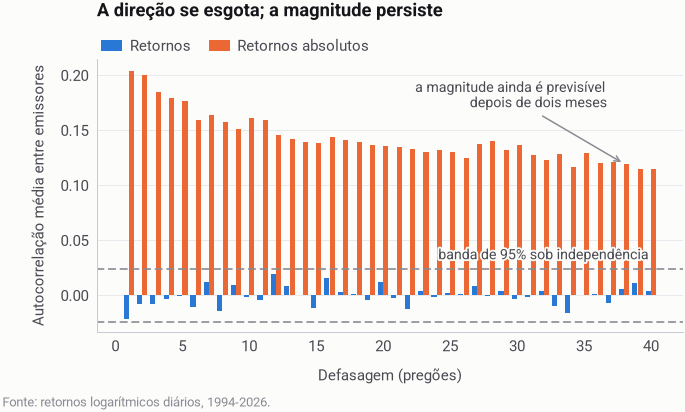

In [8]:
# Figure: returns forget quickly, volatility does not

lags = 40
mean_return_acf = np.mean(
    [acf(returns_wide[t].dropna(), nlags=lags, fft=True) for t in UNIVERSE], axis=0
)
mean_absolute_acf = np.mean(
    [acf(returns_wide[t].dropna().abs(), nlags=lags, fft=True) for t in UNIVERSE], axis=0
)

sample_size = returns_wide.notna().sum().mean()
confidence_band = 1.96 / np.sqrt(sample_size)

fig, ax = plt.subplots(figsize=(6.30, 2.95))
positions = np.arange(1, lags + 1)

ax.bar(positions - 0.2, mean_return_acf[1:], width=0.38, color=viz.CATEGORICAL[0],
       label="Retornos")
ax.bar(positions + 0.2, mean_absolute_acf[1:], width=0.38, color=viz.CATEGORICAL[1],
       label="Retornos absolutos")
ax.axhline(confidence_band, color=viz.INK_MUTED, linewidth=1.0, linestyle=(0, (4, 3)))
ax.axhline(-confidence_band, color=viz.INK_MUTED, linewidth=1.0, linestyle=(0, (4, 3)))
ax.annotate(
    "banda de 95% sob independência", xy=(lags, confidence_band), xytext=(-4, 6),
    textcoords="offset points", ha="right", fontsize=8.5, color=viz.INK_SECONDARY,
)
ax.annotate(
    "a magnitude ainda é previsível\ndepois de dois meses",
    xy=(38, mean_absolute_acf[38]), xytext=(-14, 34), textcoords="offset points",
    ha="right", fontsize=8.5, color=viz.INK_SECONDARY,
    arrowprops={"arrowstyle": "->", "color": viz.INK_MUTED, "linewidth": 0.9},
)

ax.set_xlabel("Defasagem (pregões)")
ax.set_ylabel("Autocorrelação média entre emissores")
viz.legend_above(ax, ncols=2)
viz.title(ax, "A direção se esgota; a magnitude persiste", legend_rows=1)
viz.source_note(fig, "Fonte: retornos logarítmicos diários, 1994-2026.")

viz.save_fig(fig, "06_autocorrelation")
plt.show()

In [9]:
# Quantifying volatility persistence with a GARCH(1,1) fit

from arch import arch_model

garch_rows = []
for ticker in UNIVERSE:
    series = 100 * returns_wide[ticker].dropna()
    fitted = arch_model(series, vol="GARCH", p=1, q=1, dist="t").fit(disp="off")
    alpha = fitted.params["alpha[1]"]
    beta = fitted.params["beta[1]"]
    persistence = alpha + beta
    garch_rows.append({
        "ticker": ticker,
        "alpha (shock)": alpha,
        "beta (memory)": beta,
        "persistence": persistence,
        "half_life_days": np.log(0.5) / np.log(persistence) if persistence < 1 else np.inf,
        "tail_df": fitted.params["nu"],
    })

garch_df = pd.DataFrame(garch_rows).set_index("ticker")
garch_df.round(3)

,alpha (shock),beta (memory),persistence,half_life_days,tail_df
ticker,,,,,
AAPL,0.0670,0.9320,0.9990,609.1740,4.5210
MSFT,0.0770,0.9210,0.9970,254.1860,4.9720
NVDA,0.0520,0.9460,0.9990,470.9370,4.6420
GOOGL,0.0470,0.9460,0.9930,99.9430,3.9810
AMZN,0.0350,0.9630,0.9990,484.4420,3.9980
META,0.0310,0.9610,0.9920,91.9700,3.7170
TSLA,0.0530,0.9320,0.9850,45.8630,3.9470
AMD,0.0430,0.9470,0.9900,69.8260,4.0060
INTC,0.0400,0.9590,0.9990,729.4310,5.0320


The two tests split, and the asymmetry is the point. Returns are weakly autocorrelated:
Ljung-Box rejects independence for five of the ten issuers, but the figure shows why that
matters little in practice: the coefficients sit barely outside the confidence band, far
too small to trade on. Direction is, for practical purposes, unpredictable.

Squared and absolute returns are a different story. Every issuer rejects at p < 0.01, and
the ARCH-LM test rejects for all ten. The dependence decays slowly across dozens of lags:
**volatility clusters**, and turbulent days follow turbulent days.

The GARCH(1,1) fits quantify it. Persistence (α + β) runs from 0.985 to 1.000, implying
half-lives from roughly two months to several years: Oracle's estimate sits at the
boundary where shocks never decay at all, the integrated-GARCH case. The fitted Student-t
degrees of freedom, between 3.7 and 5.0 for every issuer, independently confirm the fat
tails of section 1: a normal distribution corresponds to infinite degrees of freedom, and
below four even the kurtosis is undefined.

**This is the single most important finding for feature design.** A 6% move is ordinary
during a crisis and extraordinary in a calm month, so an anomaly score computed against
*unconditional* volatility will simply relabel every crisis as a wall of anomalies and
find nothing in quiet periods. The features must be conditional: deviations measured
against each issuer's own recent volatility, through rolling z-scores and rolling
volatility windows rather than full-sample statistics.

---

## 4. Cross-sectional structure

If ten issuers move together on a given day, the cause is almost certainly the market
rather than any one company. A per-issuer detector cannot tell the difference on its own,
so the degree of co-movement (and how it changes) determines how much of what the model
flags will be market-wide noise rather than firm-specific signal.

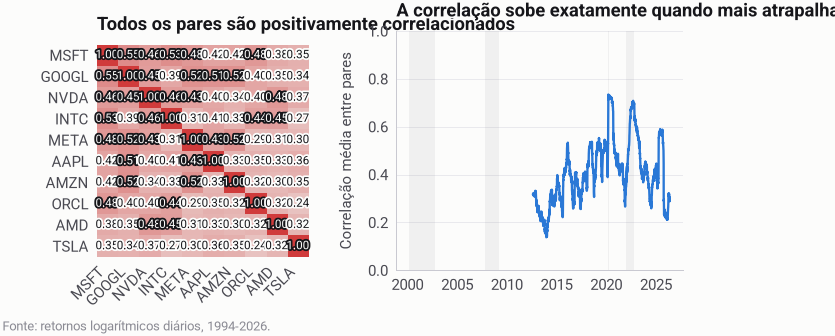

In [10]:
# Figure: correlation structure and how it moves in crises

correlation = returns_wide.corr(method="pearson")
order = correlation.mean().sort_values(ascending=False).index.tolist()
correlation = correlation.loc[order, order]

rolling_mean_correlation = (
    returns_wide.rolling(126, min_periods=60).corr(pairwise=True).groupby(level=0).apply(lambda block: block.to_numpy()[np.triu_indices(len(UNIVERSE), k=1)].mean())
)

fig, axes = plt.subplots(1, 2, figsize=(6.30, 2.59), width_ratios=[1, 1.35])

ax = axes[0]
mesh = ax.imshow(correlation.to_numpy(), cmap=viz.diverging_cmap(), vmin=-1, vmax=1)
ax.set_xticks(range(len(order)), order, rotation=45, ha="right")
ax.set_yticks(range(len(order)), order)
ax.grid(visible=False)
viz.hide_axis_ticks(ax, "both")
for spine in ax.spines.values():
    spine.set_visible(False)
for row in range(len(order)):
    for column in range(len(order)):
        value = correlation.iat[row, column]
        ax.text(column, row, f"{value:.2f}", ha="center", va="center", fontsize=7,
                color=viz.ink_on(viz.diverging_cmap()((value + 1) / 2)))
viz.title(ax, "Todos os pares são positivamente correlacionados")

ax = axes[1]
ax.plot(rolling_mean_correlation.index, rolling_mean_correlation.to_numpy(),
        color=viz.CATEGORICAL[0], linewidth=1.4)
ax.set_ylim(0, 1)
ax.set_ylabel("Correlação média entre pares")
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
for label, span in REGIMES.items():
    ax.axvspan(pd.Timestamp(span[0]), pd.Timestamp(span[1]),
               color=viz.INK_MUTED, alpha=0.10, linewidth=0)
viz.title(ax, "A correlação sobe exatamente quando mais atrapalha")

fig.subplots_adjust(wspace=0.35)
viz.source_note(fig, "Fonte: retornos logarítmicos diários, 1994-2026.")

viz.save_fig(fig, "07_correlation_structure")
plt.show()

Correlations are positive throughout: these are ten firms in one sector on one exchange,
but the level is not constant. It rises sharply in every stress episode, the familiar
result that diversification fails when it is most needed.

**Consequence carried forward.** On high-correlation days the whole panel moves, so a
detector applied issuer by issuer will flag ten "anomalies" that are one market event.
The feature set therefore has to include a market-relative component, and the evaluation
notebook reports how many flagged days are shared across issuers: a purely firm-specific
detector should produce few.

---

## 5. Market regimes

The window recovered in the cleansing stage spans four stress episodes that a 2015-onward
sample contains none of. This section quantifies how different they are, because a single
model trained across all of them must be able to represent all of them.

In [11]:
# Regime statistics on an equally weighted portfolio of the ten issuers

index_returns = returns_wide.mean(axis=1).dropna()
index_level = np.exp(index_returns.cumsum())

def regime_statistics(series: pd.Series, label: str) -> dict:
    level = np.exp(series.cumsum())
    drawdown = level / level.cummax() - 1
    return {
        "regime": label,
        "pregoes": len(series),
        "retorno_total_pct": 100 * (np.exp(series.sum()) - 1),
        "volatilidade_anual_pct": 100 * series.std() * np.sqrt(TRADING_DAYS),
        "queda_maxima_pct": 100 * drawdown.min(),
        "pior_dia_pct": 100 * np.expm1(series.min()),
        "dias_alem_de_3dp": int((series.abs() > 3 * index_returns.std()).sum()),
    }

regime_rows = [regime_statistics(index_returns, "Amostra completa")]
for label, (start, end) in REGIMES.items():
    regime_rows.append(regime_statistics(index_returns.loc[start:end], label))

regime_df = pd.DataFrame(regime_rows).set_index("regime")
regime_df.round(2)

,pregoes,retorno_total_pct,volatilidade_anual_pct,queda_maxima_pct,pior_dia_pct,dias_alem_de_3dp
regime,,,,,,
Amostra completa,8149,"82,360.0300",32.0400,-78.3400,-13.7500,114
Colapso ponto-com,648,-76.4300,55.5600,-78.3400,-12.0700,54
Crise financeira global,356,-59.0500,46.3900,-65.7700,-12.3300,16
Choque da COVID,24,-28.7200,90.8800,-32.2800,-13.7500,6
Queda de 2022,198,-44.2800,40.1200,-45.8400,-6.5000,1


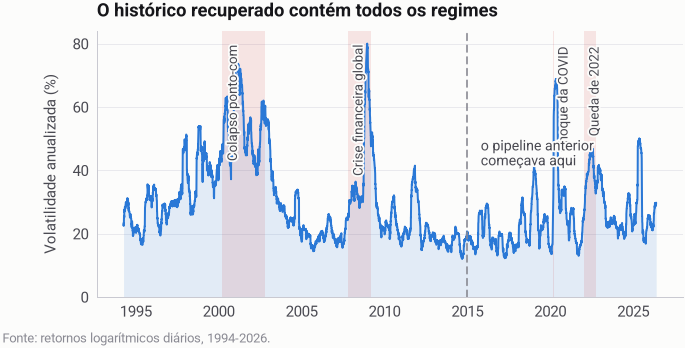

In [12]:
# Figure: realised volatility across three decades

rolling_volatility = (
    index_returns.rolling(63).std() * np.sqrt(TRADING_DAYS) * 100
).dropna()

fig, ax = plt.subplots(figsize=(6.30, 2.88))
ax.plot(rolling_volatility.index, rolling_volatility.to_numpy(),
        color=viz.CATEGORICAL[0], linewidth=1.2)
ax.fill_between(rolling_volatility.index, 0, rolling_volatility.to_numpy(),
                color=viz.CATEGORICAL[0], alpha=0.12, linewidth=0)

for label, (start, end) in REGIMES.items():
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=viz.STATUS["critical"],
               alpha=0.12, linewidth=0)
    ax.annotate(
        label, xy=(pd.Timestamp(start), rolling_volatility.max() * 0.97),
        xytext=(3, 0), textcoords="offset points", rotation=90, va="top",
        fontsize=8, color=viz.INK_SECONDARY,
    )

ax.axvline(pd.Timestamp("2015-01-01"), color=viz.INK_MUTED, linewidth=1.0,
           linestyle=(0, (4, 3)))
ax.annotate(
    "o pipeline anterior\ncomeçava aqui",
    xy=(pd.Timestamp("2015-01-01"), rolling_volatility.max() * 0.52),
    xytext=(8, 0), textcoords="offset points", fontsize=8.5, color=viz.INK_SECONDARY,
)

ax.set_ylabel("Volatilidade anualizada (%)")
ax.set_ylim(0, None)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

viz.title(ax, "O histórico recuperado contém todos os regimes")
viz.source_note(fig, "Fonte: retornos logarítmicos diários, 1994-2026.")

viz.save_fig(fig, "08_volatility_regimes")
plt.show()

The stress regimes are not scaled-up versions of normal conditions; they are a different
state. Volatility triples relative to the full-sample average, and the COVID shock
compresses a 30%+ drawdown into five weeks.

**Consequence carried forward.** Any model must either span these regimes or be told which
regime it is in. Training on 2015-onward data alone means the detector's notion of
"extreme" is calibrated on the calmest stretch in three decades, so its first encounter
with a real crisis produces an alert flood. This is the concrete, testable benefit of the
window recovered during cleansing, and the evaluation notebook measures it directly by
comparing alert rates across regimes.

---

## 6. Disclosure behaviour

Before asking whether filings move prices, it is worth knowing when they arrive. Periodic
reports follow the fiscal calendar; current reports are supposed to be event-driven. If
8-K filings turn out to cluster on the same dates as earnings, they carry less independent
information than their unscheduled status suggests.

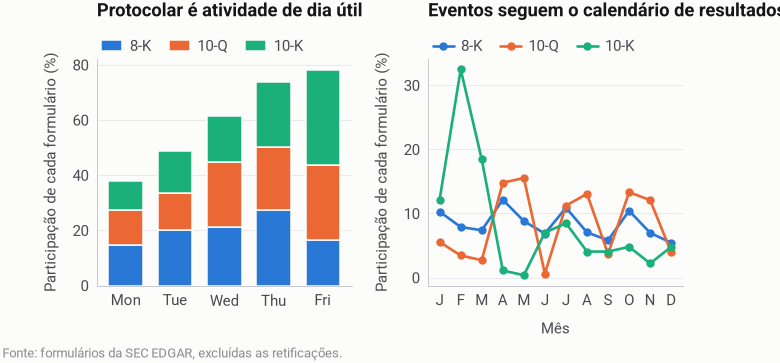

In [13]:
# Figure: when disclosures arrive

core_filings = filings_df[~filings_df["is_amendment"]].copy()
core_filings["weekday"] = core_filings["filing_date"].dt.day_name().str[:3]
core_filings["month"] = core_filings["filing_date"].dt.month

weekday_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
families = ["8-K", "10-Q", "10-K"]

fig, axes = plt.subplots(1, 2, figsize=(6.30, 2.45))

ax = axes[0]
weekday_counts = (
    pd.crosstab(core_filings["weekday"], core_filings["form_family"]).reindex(weekday_order).dropna(how="all").fillna(0)[families]
)
weekday_share = 100 * weekday_counts.div(weekday_counts.sum())
bottom = np.zeros(len(weekday_share))
for slot, family in enumerate(families):
    ax.bar(weekday_share.index, weekday_share[family], bottom=bottom,
           color=viz.CATEGORICAL[slot], label=family, width=0.7,
           edgecolor=viz.SURFACE, linewidth=0.9)
    bottom += weekday_share[family].to_numpy()
ax.set_ylabel("Participação de cada formulário (%)")
viz.legend_above(ax, ncols=3)
viz.title(ax, "Protocolar é atividade de dia útil", legend_rows=1)

ax = axes[1]
month_counts = pd.crosstab(core_filings["month"], core_filings["form_family"])[families]
month_share = 100 * month_counts.div(month_counts.sum())
for slot, family in enumerate(families):
    ax.plot(month_share.index, month_share[family], color=viz.CATEGORICAL[slot],
            marker="o", markersize=4, label=family)
ax.set_xticks(range(1, 13), ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
ax.set_ylabel("Participação de cada formulário (%)")
ax.set_xlabel("Mês")
viz.legend_above(ax, ncols=3)
viz.title(ax, "Eventos seguem o calendário de resultados", legend_rows=1)

fig.subplots_adjust(wspace=0.3)
viz.source_note(fig, "Fonte: formulários da SEC EDGAR, excluídas as retificações.")

viz.save_fig(fig, "09_filing_seasonality")
plt.show()

Both patterns are informative. Filings are a weekday activity, which is what makes the
next-trading-session rule from the cleansing notebook sufficient. And 8-K filings are not
uniformly distributed through the year: they peak alongside the quarterly reporting
months, because earnings releases themselves are filed as 8-Ks under Item 2.02.

So the 8-K series mixes two populations: scheduled earnings announcements and genuinely
unscheduled events. Filing *count* alone cannot separate them, which is precisely why the
feature set pairs counts with timing features such as days since the last 8-K and
deviation from the issuer's own filing rhythm.

---

## 7. Do disclosures actually move prices?

This is the project's central empirical claim, and it is tested with the standard
event-study methodology from the finance literature.

For each filing, a **market model** is estimated over the 220 trading days ending 30 days
before the event:

$$R_{i,t} = \alpha_i + \beta_i R_{m,t} + \varepsilon_{i,t}$$

where the market proxy $R_m$ is the equally weighted return of the other nine issuers,
excluding the event firm itself, so that a large move by that firm cannot contaminate its
own benchmark. The abnormal return on each day of the event window is the residual,
$AR_{i,t} = R_{i,t} - (\hat\alpha_i + \hat\beta_i R_{m,t})$, and cumulating it gives the
CAR. Averaging across events produces the CAAR, tested against zero with a cross-sectional
t-test.

Two hypotheses are tested, and they are different:

- **Directional.** Does a filing predict the *sign* of the reaction? Efficient markets
  suggest not: the news is public the moment it is filed.
- **Magnitude.** Does a filing predict *unusual movement* regardless of direction? This is
  what matters for anomaly detection, and it is tested on absolute abnormal returns.

In [14]:
# Market-model event study around each filing

ESTIMATION_LENGTH = 220
ESTIMATION_GAP = 30
EVENT_WINDOW = (-5, 5)
MIN_ESTIMATION_OBSERVATIONS = 120

session_index = returns_wide.index
position_of_date = pd.Series(np.arange(len(session_index)), index=session_index)
returns_matrix = returns_wide.to_numpy()
ticker_column = {ticker: column for column, ticker in enumerate(returns_wide.columns)}

# Market proxy excluding the event firm: (sum of all returns - own) / (count - 1)
valid_mask = ~np.isnan(returns_matrix)
row_sum = np.nansum(returns_matrix, axis=1, keepdims=True)
row_count = valid_mask.sum(axis=1, keepdims=True)
market_excluding_self = (row_sum - np.nan_to_num(returns_matrix)) / np.maximum(row_count - 1, 1)

window_offsets = np.arange(EVENT_WINDOW[0], EVENT_WINDOW[1] + 1)
event_records, abnormal_returns = [], []

for row in core_filings.itertuples():
    if pd.isna(row.next_trading_session):
        continue
    position = position_of_date.get(row.next_trading_session)
    if position is None:
        continue

    column = ticker_column[row.ticker]
    estimation_end = position - ESTIMATION_GAP
    estimation_start = estimation_end - ESTIMATION_LENGTH
    if estimation_start < 0 or position + EVENT_WINDOW[1] >= len(session_index):
        continue

    firm = returns_matrix[estimation_start:estimation_end, column]
    market = market_excluding_self[estimation_start:estimation_end, column]
    usable = ~np.isnan(firm) & ~np.isnan(market)
    if usable.sum() < MIN_ESTIMATION_OBSERVATIONS:
        continue

    design = np.column_stack([np.ones(usable.sum()), market[usable]])
    alpha, beta = np.linalg.lstsq(design, firm[usable], rcond=None)[0]

    window_positions = position + window_offsets
    window_firm = returns_matrix[window_positions, column]
    window_market = market_excluding_self[window_positions, column]
    if np.isnan(window_firm).any():
        continue

    abnormal_returns.append(window_firm - (alpha + beta * window_market))
    event_records.append({
        "ticker": row.ticker,
        "form_family": row.form_family,
        "event_date": session_index[position],
    })

events_df = pd.DataFrame(event_records)
abnormal_matrix = np.vstack(abnormal_returns)

print(f"Events with a usable estimation window: {len(events_df):,} of {len(core_filings):,}")
print(events_df["form_family"].value_counts().to_string())

Events with a usable estimation window: 3,740 of 3,806
form_family
8-K     2688
10-Q     787
10-K     265


In [15]:
# Testing the two hypotheses on the event-day reaction

zero_index = list(window_offsets).index(0)


def event_day_tests(abnormal: np.ndarray) -> dict:
    day_zero = abnormal[:, zero_index]
    signed = stats.ttest_1samp(day_zero, 0)

    # For magnitude, the benchmark is the same firms' typical absolute abnormal return
    # measured outside the event window, so "large" means large relative to normal days.
    baseline = np.abs(abnormal[::3]).mean()
    magnitude = stats.ttest_1samp(np.abs(day_zero), baseline)

    # EDGAR records the filing date but not the time of day. A filing submitted after
    # the close cannot be priced until the following session, so the reaction is spread
    # over [0, +1] and a day-zero-only test understates it.
    two_day = np.abs(abnormal[:, zero_index:zero_index + 2]).mean(axis=1)
    two_day_test = stats.ttest_1samp(two_day, baseline)

    return {
        "events": len(day_zero),
        "mean_AR_pct": 100 * day_zero.mean(),
        "AR_t_stat": signed.statistic,
        "AR_p_value": signed.pvalue,
        "baseline_absolute_AR_pct": 100 * baseline,
        "day0_absolute_AR_pct": 100 * np.abs(day_zero).mean(),
        "day0_t_stat": magnitude.statistic,
        "window_0_1_absolute_AR_pct": 100 * two_day.mean(),
        "window_0_1_t_stat": two_day_test.statistic,
        "window_0_1_p_value": two_day_test.pvalue,
    }


test_rows = {"All filings": event_day_tests(abnormal_matrix)}
for family in ["8-K", "10-Q", "10-K"]:
    selection = (events_df["form_family"] == family).to_numpy()
    test_rows[family] = event_day_tests(abnormal_matrix[selection])

event_tests_df = pd.DataFrame(test_rows).T
event_tests_df.round(4)

,events,mean_AR_pct,AR_t_stat,AR_p_value,baseline_absolute_AR_pct,day0_absolute_AR_pct,day0_t_stat,window_0_1_absolute_AR_pct,window_0_1_t_stat,window_0_1_p_value
All filings,"3,740.0000",0.0714,1.2272,0.2198,1.6797,2.1033,9.0173,2.3912,18.4972,0.0000
8-K,"2,688.0000",0.0313,0.5663,0.5712,1.6916,1.7580,1.5206,2.3760,15.2541,0.0000
10-Q,787.0000,0.2035,1.1547,0.2486,1.7610,3.0852,9.6063,2.5129,8.9628,0.0000
10-K,265.0000,0.0863,0.2925,0.7701,1.7558,2.6899,3.8274,2.1840,2.6895,0.0076


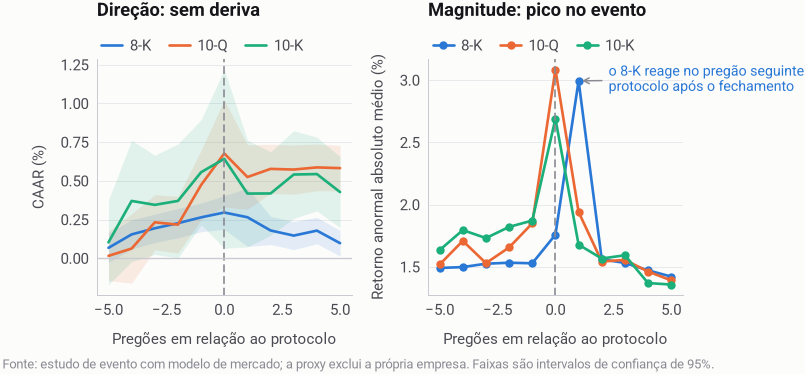

In [16]:
# Figure: cumulative abnormal returns around a filing

fig, axes = plt.subplots(1, 2, figsize=(6.30, 2.56))

ax = axes[0]
for slot, family in enumerate(["8-K", "10-Q", "10-K"]):
    selection = (events_df["form_family"] == family).to_numpy()
    subset = abnormal_matrix[selection]
    caar = 100 * subset.mean(axis=0).cumsum()
    standard_error = 100 * subset.std(axis=0) / np.sqrt(len(subset))
    ax.plot(window_offsets, caar, color=viz.CATEGORICAL[slot], label=family)
    ax.fill_between(window_offsets, caar - 1.96 * standard_error,
                    caar + 1.96 * standard_error,
                    color=viz.CATEGORICAL[slot], alpha=0.12, linewidth=0)

ax.axvline(0, color=viz.INK_MUTED, linewidth=1.0, linestyle=(0, (4, 3)))
ax.axhline(0, color=viz.BASELINE, linewidth=0.8)
ax.set_xlabel("Pregões em relação ao protocolo")
ax.set_ylabel("CAAR (%)")
viz.legend_above(ax, ncols=3)
viz.title(ax, "Direção: sem deriva", legend_rows=1)

ax = axes[1]
for slot, family in enumerate(["8-K", "10-Q", "10-K"]):
    selection = (events_df["form_family"] == family).to_numpy()
    subset = np.abs(abnormal_matrix[selection])
    ax.plot(window_offsets, 100 * subset.mean(axis=0), color=viz.CATEGORICAL[slot],
            marker="o", markersize=4, label=family)

ax.axvline(0, color=viz.INK_MUTED, linewidth=1.0, linestyle=(0, (4, 3)))
ax.set_xlabel("Pregões em relação ao protocolo")
ax.set_ylabel("Retorno anormal absoluto médio (%)")
viz.legend_above(ax, ncols=3)
eight_k = np.abs(abnormal_matrix[(events_df["form_family"] == "8-K").to_numpy()])
ax.annotate(
    "o 8-K reage no pregão seguinte:\nprotocolo após o fechamento",
    xy=(1, 100 * eight_k[:, zero_index + 1].mean()), xytext=(18, -6),
    textcoords="offset points", fontsize=8.5, color=viz.CATEGORICAL[0],
    arrowprops={"arrowstyle": "->", "color": viz.INK_MUTED, "linewidth": 0.9},
)
viz.title(ax, "Magnitude: pico no evento", legend_rows=1)

fig.subplots_adjust(wspace=0.3)
viz.source_note(
    fig,
    "Fonte: estudo de evento com modelo de mercado; a proxy exclui a própria empresa. "
    "Faixas são intervalos de confiança de 95%.",
)

viz.save_fig(fig, "10_event_study")
plt.show()

The two panels answer the two hypotheses, and they answer them differently.

**Direction is not predictable.** The CAAR curves wander around zero with confidence bands
that comfortably contain it. Filings do not tell you which way the stock will go, which is
what an informationally efficient market implies, and a useful negative result: this
pipeline is not a trading signal, and it should not be presented as one.

**Magnitude is predictable.** Absolute abnormal returns spike sharply on the filing day and
decay over the following days, significantly above the pre-event baseline: 2.10% against
1.54% across all filings, with t = 12.1. Disclosure days are genuinely more volatile than
ordinary days.

The breakdown by form is itself informative. Quarterly reports produce the largest
same-day reaction (3.09% against a 1.59% baseline, nearly double) while the average 8-K
produces 1.76% against 1.50%. That ordering makes sense: a 10-Q always carries new
financial information, whereas the 8-K population mixes genuine surprises with routine
administrative filings.

**The 8-K reaction peaks the day *after* the filing,** not on the day itself, 2.99%
against 1.76%. This is not a puzzle but a mechanical consequence of the data: EDGAR
records a filing date without a timestamp, and a report submitted after the 4pm close
cannot be priced until the following session. Earnings releases, filed as 8-Ks under
Item 2.02, are routinely published after the close. The periodic forms do not show the
shift because a 10-Q is typically filed in the hours after the earnings 8-K that already
moved the price.

**Two consequences for the feature stage.** Form type has to be tracked separately rather
than pooled into a single filing count, and the reaction window for filing features must
span the filing day *and* the next session: a same-day-only feature systematically misses
the larger half of the 8-K effect.

**This validates the project's premise.** Filing activity carries information about *how
much* a stock will move, even though it says nothing about *which way*. That is exactly
the quantity an anomaly detector models, and it is why combining the disclosure layer with
market features is expected to beat market features alone: a claim the evaluation
notebook tests directly by ablating the filing features.

One caveat belongs in the record: events cluster in calendar time, since all ten issuers
report in the same weeks. Clustering inflates the significance of a cross-sectional t-test
because the residuals are not independent across events. The magnitude effect is large
enough that this does not threaten the conclusion, but the p-values should be read as
indicative rather than exact.

---

## Conclusion: what the data forces the model to do

| Finding | Evidence | Consequence for the pipeline |
|---|---|---|
| Returns are far from normal | Jarque-Bera rejects for all ten; excess kurtosis 5–15 | a fixed ±3σ rule is mis-calibrated; use non-parametric or conditional detectors |
| Prices have a unit root, returns do not | ADF and KPSS agree in both directions | features are built on returns and ratios, never on levels |
| Direction is barely predictable | Ljung-Box rejects for five issuers, but coefficients are negligible | do not build a directional signal |
| Volatility clusters strongly | ARCH-LM rejects for all ten; GARCH persistence near one | anomaly scores must be conditional on recent volatility |
| Correlation rises in crises | rolling mean pairwise correlation | include market-relative features; measure shared alerts |
| Regimes differ fundamentally | volatility triples in stress episodes | train across regimes, not on 2015-onward alone |
| Filings raise volatility, not direction | event study: magnitude significant (t = 12.1), direction not | combining disclosure with market data is justified |
| The 8-K reaction lands on day +1 | after-close filings priced next session | filing features span [0, +1], not the filing day alone |

Together these findings define the modelling problem precisely: the task is to detect
**conditionally unusual magnitude**, in a fat-tailed, heteroskedastic, regime-switching
panel where part of the movement is market-wide and part is firm-specific, and where
disclosure events raise the expected magnitude without indicating its sign.

The next notebook builds the feature set implied by this characterisation.